In [145]:
#importing basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import os
import numpy as np

In [146]:
path = "/user/work/gp15776/abyu_wt/exo/pose_2/us_dftb"

In [147]:
# Number of files
n_files = 10

# Read all files from the path
dfs = []
for i in range(1, n_files + 1):
    file_path = os.path.join(path, f"wham_{i}.dat")
    df = pd.read_csv(file_path, sep='\s+', comment='#', header=None)
    dfs.append(df)

# First column from the first file
coor = dfs[0].iloc[:, 0]

# Second column from each file
cols = [df.iloc[:, 1] for df in dfs]

# Combine columns side by side
combined = pd.concat([coor] + cols, axis=1)

# Save as comma-separated CSV file, without header
output_file = os.path.join(path, "wham_all.csv")
combined.to_csv(output_file, index=False, header=False)

print(f"✅ Combined file saved (no header): {output_file}")

✅ Combined file saved (no header): /user/work/gp15776/abyu_wt/exo/pose_2/us_dftb/wham_all.csv


<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_2831176/2802893783.py:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(file_path, sep='\s+', comment='#', header=None)


In [148]:
#input as a command line prompt - no inside names as easy to confuse and not so easily applicable
#filename=input("Enter name of input file: ")
filename=os.path.join(path, f"wham_all")

In [149]:
#read data, assume that 'inf' are NaN; since column names may differ between runs (sometimes its "US10, US20..." and sometimes its "US1, US2...") the column names for further visualisation are gives by the loop below for consistency
data=pd.read_csv(filename+".csv", na_values="inf")
column_names=[]
work_columns=[]
j=10
for i in range(1,(data.shape[1]+1)):
    if i == 1:
        column_names.append("Coord")
    else:
        column_names.append("US"+str(j))
        work_columns.append("US"+str(j))
        j+=10
data.columns=column_names

In [150]:
#Primar transformation of a data - looking for minimum and shifting the data up/down

In [151]:
#Get a minimum value in each "US" column and then substract it from all rows - shifting all columns 
#find minimum
for i in work_columns:
    new_col=[]
    for j in data[i]:
        k=j-data[(data["Coord"]>=2.5)][i].min()
        new_col.append(k)
    data[i]=new_col

In [152]:
print(data.loc[17, data.columns[1:11]].std())

1.2614164041369609


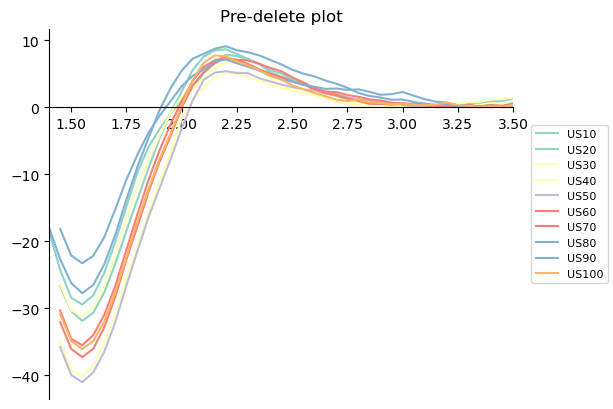

In [153]:
#plot final figure - adjust so the xaxis is in y=0 - colours based on answers from: https://stackoverflow.com/questions/8931268/using-colormaps-to-set-color-of-line-in-matplotlib
Ncolors = 20
colormap = plt.cm.Set3 #choosing colormaps
mapcolors = [colormap(int(x*colormap.N/Ncolors)) for x in range(Ncolors)]
l_styles = ['-'] #if in the future I want to change linestyle
m_styles = [''] #if in the future I want to add marker
fig,ax = plt.subplots(gridspec_kw=dict(right=0.85))
for i,(marker,linestyle,color) in zip(work_columns,itertools.product(m_styles,l_styles, mapcolors)):
    ax.plot(data["Coord"],data[i], color=color, linestyle=linestyle,marker=marker,label=i)
plt.xlim(1.4,3.5)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
plt.title("Pre-delete plot")
fig.legend(loc="right", ncol=1,prop={'size': 8})
plt.show()

In [154]:
#Odd graphs out - if one specific line stands out too much from the rest that is the sign that this one run should be recalculated. The code below informs user about  that
odd_out=[]
for i in work_columns:
    odd=[]
    for j in range(1,len(data[(data["Coord"]>=2.5)][i])):
        if data[(data["Coord"]>=2.0)].loc[j+14,i] > data[(data["Coord"]>=2.0)].loc[j+14-1,i]:
            odd.append("1")
    if len(odd)>10:
        odd_out.append(i)
        print(f"You might need to recalculate {i}")

In [155]:
if input('Do you want to delete columns? y/n ') == 'y':
    columns=input(f"Which columns do you want to delete (Type number 1 to {len(work_columns)} separated by space) ")
    delete_columns=columns.split(" ")
    delete_columns=["US"+str(eval(i)*10) for i in delete_columns]
    work_columns=[i for i in work_columns if i not in delete_columns]
    del_col=[]
    for i in delete_columns: 
        loc=data.columns.get_loc(i)
        loc_list=[loc]
        del_col.extend(loc_list)
    data.drop(data.columns[del_col], axis=1, inplace=True)

In [156]:
data.columns.values[0] = "Coord"

In [157]:
min=data.loc[5,work_columns[2]].min()

In [158]:
# If the spread of the graphs, after deleting outstanding lines, in x<=2 is bigger than 20 kcal/mol - print a warning 
min=data[(data["Coord"]<=2.0)].loc[5,work_columns[0]].min()
max=data[(data["Coord"]<=2.0)].loc[5,work_columns[0]].max()
for i in [i for i in list(data.columns.values) if i not in odd_out]:
    new_min=data[(data["Coord"]<=2.0)].loc[5,i].min()
    new_max=data[(data["Coord"]<=2.0)].loc[5,i].max()
    if new_min<min:
        min=new_min
    if new_max>max:
        max=new_max
    diff=max-min
if diff > 20:
    print("The spread is high")

The spread is high


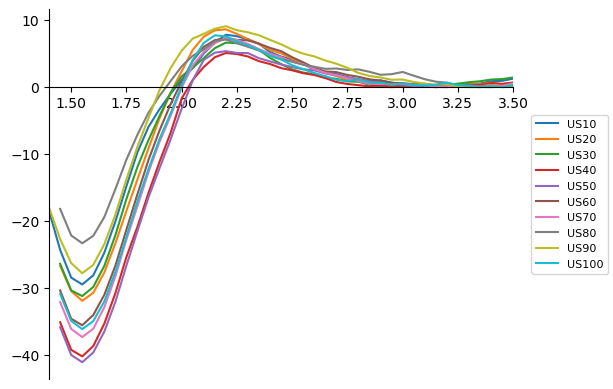

In [159]:
Ncolors = len(work_columns)
colormap = plt.cm.tab20 #choosing colormaps
mapcolors = [colormap(int(x*colormap.N/Ncolors)) for x in range(Ncolors)]
l_styles = ['-'] #if in the future I want to change linestyle
m_styles = [''] #if in the future I want to add marker
fig1,ax = plt.subplots(gridspec_kw=dict(right=0.85))
for i,(marker,linestyle,color) in zip(work_columns,itertools.product(m_styles,l_styles, mapcolors)):
    ax.plot(data["Coord"],data[i], color=color, linestyle=linestyle,marker=marker,label=i)
plt.xlim(1.4,3.5)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
fig1.legend(loc="right", ncol=1,prop={'size': 8})
title=input("What is the title of the plot? ")
plt.title(title)
fig1.savefig(filename+".png")
plt.show()

In [160]:
#If there are more than one graph ask for it and continue with the above until all the graphs are done. Then connect them all in one picture and save apart from saving them separately

In [161]:
!cat {path}/*/*/*.tra > {path}/all.tra

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_2831176/1335373849.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(file_path, sep='\s+', header=None)


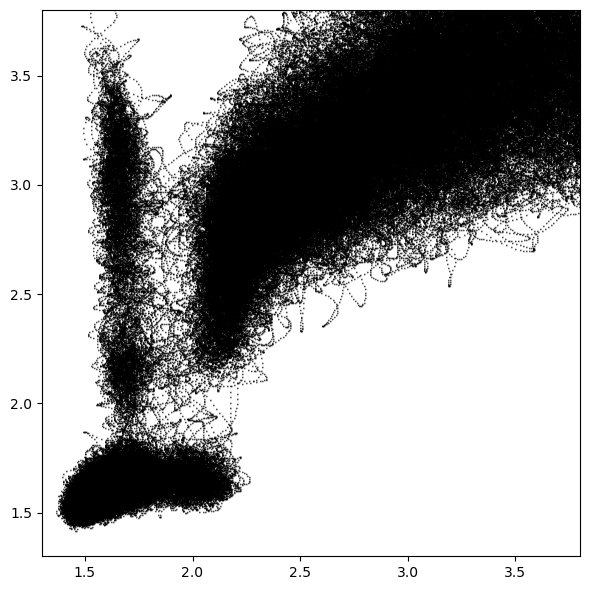

In [162]:
file_path = os.path.join(path, f"all.tra")  # change if needed

# Read the file (space- or tab-separated, no header)
df = pd.read_csv(file_path, sep='\s+', header=None)

# Plot: column 3 vs column 4
plt.figure(figsize=(6, 6))
plt.scatter(df.iloc[:, 2], df.iloc[:, 3], s=0.05, marker=8, color='black')  # smallest black points

# Labels and title (optional)
#plt.xlabel("Column 3")
#plt.ylabel("Column 4")
#plt.title("Column 3 vs Column 4")

# Limit axes
plt.xlim(1.3, 3.8)
plt.ylim(1.3, 3.8)

# No grid, minimal styling
plt.grid(False)
plt.tight_layout()

#plt.show()
filename=os.path.join(path, f"all_tra")
plt.savefig(filename+".png", dpi=300, bbox_inches='tight')


<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_2831176/1111858303.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(file_path, sep='\s+', comment='#', header=None)


Maximum normalized value: 7.1 at RC = 2.2


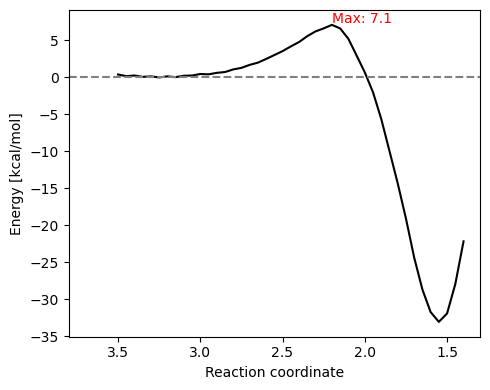

In [163]:
# Use your previously defined path variable and filename
file_path = os.path.join(path, "mega_wham_2ps.dat")  # <- replace with actual filename

# Read the file (skip header, whitespace-separated)
df = pd.read_csv(file_path, sep='\s+', comment='#', header=None)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Extract first and second columns
x = df.iloc[:, 0].values  # Coor
y = df.iloc[:, 1].values  # Free

# --- get errors from column 3 (index 11) ---
#errors = df.iloc[:, 5].values  # 3th column -> index 2

# Find the lowest point in y between x = 2.5 and 3.8
mask = (x >= 2.5) & (x <= 3.8)
min_val = np.nanmin(y[mask])

# Normalize y by subtracting the minimum
y_norm = y - min_val

# Max value ignoring NaN
finite_mask = ~np.isnan(y_norm)
max_value = y_norm[finite_mask].max()
max_x = x[finite_mask][y_norm[finite_mask].argmax()]

print(f"Maximum normalized value: {max_value:.1f} at RC = {max_x}")

# Prepare mask for the x-range where we want error bars (2.0 to 2.5)
#error_mask = (x >= 2.0) & (x <= 2.5)

# Also require that y_norm and errors are finite at those points
#valid_error_points = error_mask & ~np.isnan(y_norm) & ~np.isnan(errors)

# Plot smooth line (points connected)
plt.figure(figsize=(5, 4))
plt.plot(x, y_norm, color='black', linestyle='-')  # line connecting points

# Plot error bars only for the selected valid points
# fmt='o' draws small markers at the error-bar points; remove fmt to hide markers
# plt.errorbar(x[valid_error_points], y_norm[valid_error_points],
#              yerr=errors[valid_error_points],
#              fmt='o', color='red', ecolor='red', elinewidth=1, capsize=2, markersize=3)

plt.axhline(0, color='gray', linestyle='--')       # horizontal gray dashed line at y=0

# Annotate max value on the graph
plt.text(max_x, max_value + 0.2, f"Max: {max_value:.1f}", color='red')

plt.xlabel("Reaction coordinate")
plt.ylabel("Energy [kcal/mol]")

# Reverse x-axis
plt.xlim(3.8, 1.3)

# Minimal style
plt.grid(False)
plt.tight_layout()


filename=os.path.join(path, f"wham_avg")
plt.savefig(filename+".png", dpi=300, bbox_inches='tight')
